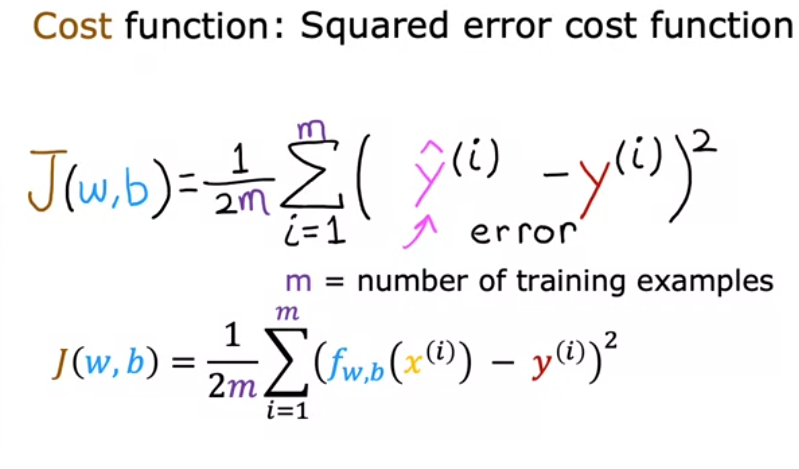

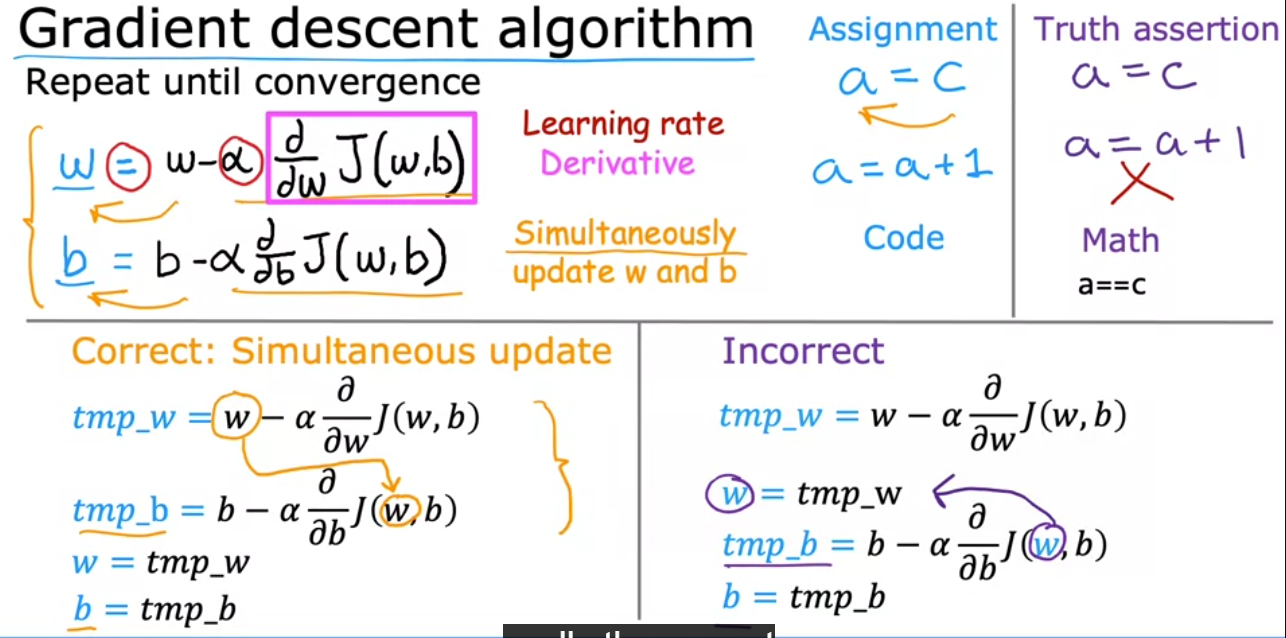

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('student_performance_dataset.csv')
df.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [4]:
df = df.dropna()
# Important for proper gradient descent

In [5]:
df.columns

Index(['student_id', 'age', 'gender', 'city_type', 'study_hours_per_day',
       'deep_work_sessions', 'assignment_completion_rate',
       'attendance_percentage', 'social_media_hours',
       'doomscrolling_before_sleep', 'notification_distractions',
       'ai_tool_usage_hours', 'gaming_hours', 'stress_level',
       'motivation_level', 'focus_score', 'procrastination_index',
       'mental_state', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'learning_style', 'career_goal',
       'productivity_after_midnight', 'revision_efficiency', 'burnout_risk',
       'consistency_score', 'final_exam_score', 'performance_category'],
      dtype='object')

In [6]:
X = df.drop(['student_id', 'final_exam_score', 'performance_category'], axis=1)
y = df['final_exam_score']

##### One-Hot Encode Categorical Columns

In [7]:
X = pd.get_dummies(X, drop_first=True)

In [8]:
feature_names = X.columns.tolist()

##### Convert to NumPy arrays

In [9]:
X = X.astype(float).to_numpy()
y = y.astype(float).to_numpy()

In [10]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

print("NaNs in X :", np.isnan(X).sum())
print("NaNs in y :", np.isnan(y).sum())

X Shape : (2823, 37)
y Shape : (2823,)
NaNs in X : 0
NaNs in y : 0


#### Feature Scaling

In [11]:
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)

# Prevent division by zero
X_std[X_std == 0] = 1

X = (X - X_mean) / X_std

##### Model Training

In [12]:
m, n = X.shape

w = np.zeros(n)
b = 0.0

In [13]:
learning_rate = 0.01
epochs = 2000

In [14]:
loss_history = []

for epoch in range(epochs):

    # Forward Pass
    y_hat = X @ w + b

    # Cost Function
    loss = np.sum((y_hat - y) ** 2) / (2 * m)
    loss_history.append(loss)

    # Gradients
    error = y_hat - y

    dw = 1/m * (X.T @ error) 
    db = 1/m * np.sum(error)

    # Gradient Descent
    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 200 == 0:
        print(f"Epoch {epoch}  Loss = {loss:.4f}")

Epoch 0  Loss = 1677.8723
Epoch 200  Loss = 62.0915
Epoch 400  Loss = 32.9974
Epoch 600  Loss = 32.4433
Epoch 800  Loss = 32.4266
Epoch 1000  Loss = 32.4245
Epoch 1200  Loss = 32.4240
Epoch 1400  Loss = 32.4238
Epoch 1600  Loss = 32.4238
Epoch 1800  Loss = 32.4238


In [15]:
print("Weights:")
print(w)

print("\nBias:")
print(b)

Weights:
[-1.73028237e-01  5.94177519e+00  2.00403243e+00  3.60275269e+00
  2.94546655e+00 -3.25170516e+00 -2.44429110e+00 -3.87670778e-01
 -2.37953596e-01 -3.45014052e-02 -3.71793715e+00  4.02701816e+00
  5.62639056e+00 -5.75508659e+00  2.03229451e+00 -3.30474069e-02
  2.96280397e-01 -1.69968526e-01  2.95804183e-01 -2.30332426e+00
  6.85054076e-02  4.06656780e+00 -4.20697996e+00  6.05268450e+00
 -3.71876691e-02 -1.38398131e-02 -8.71288934e-02 -4.54580747e+00
 -3.64648337e-01  3.13059902e+00  3.99744915e-02  1.16464042e-01
 -3.22911847e-01  8.54322722e-02 -3.31855470e-01 -5.11832553e-03
  6.61351507e-02]

Bias:
54.820757956630146


#### Prediction on Training Data

In [16]:
y_pred = X @ w + b
y_pred

array([29.7702545 , 58.46113309, 24.78397238, ..., 53.40182157,
       89.12246619, 99.07662157], shape=(2823,))

In [17]:
comparison = pd.DataFrame({
    "Actual": y,
    "Predicted": np.round(y_pred,2)
})

comparison.head(10)

,Actual,Predicted
0,32.0,29.77
1,59.0,58.46
2,34.0,24.78
3,60.0,66.75
4,77.0,84.11
5,56.0,57.18
6,74.0,65.07
7,88.0,75.28
8,81.0,75.67
9,71.0,58.67


In [18]:
loss = np.sum((y_pred - y) ** 2)/(2*m)

print("Final Loss:", loss)

Final Loss: 32.423753752633075


##### Gradients

https://chatgpt.com/s/t_6a3ec4ce29d48191a6523343d9c3f69a

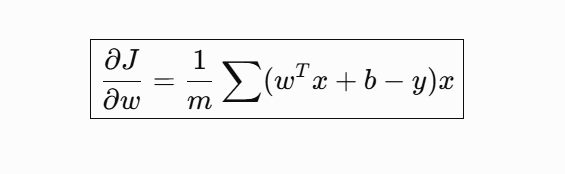
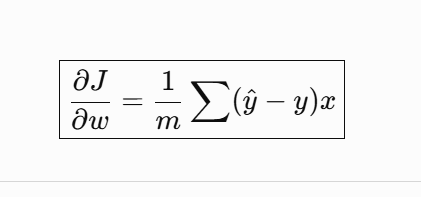

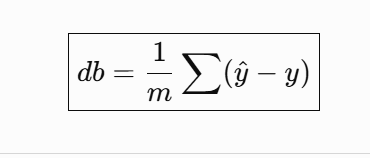

In [19]:
# error = w^t*x + b - y  where y^ = w^t*x+b
# dw = (1 / m) * (X.T @ error)
# db = (1 / m) * np.sum(error)

#### Gradient Descent

In [20]:
# learning_rate = 0.01
# w = w - learning_rate * dw
# b = b - learning_rate * db

Load Dataset

      ↓

Handle Missing Values

      ↓

Split into X and y

      ↓

One-Hot Encode Categorical Features

      ↓

Convert to NumPy

      ↓

Initialize w and b

      ↓

FOR each epoch:

    Compute ŷ = X @ w + b

    ↓

    Compute Cost

    ↓

    Compute Gradients

    ↓

    Update w and b

END FOR

      ↓
      
Final trained model

### TESTING

In [21]:
new_student = pd.DataFrame([{

    "age":20,
    "gender":"Male",
    "city_type":"Urban",

    "study_hours_per_day":6,
    "deep_work_sessions":3,

    "assignment_completion_rate":90,
    "attendance_percentage":95,

    "social_media_hours":2,
    "doomscrolling_before_sleep":1,
    "notification_distractions":5,

    "ai_tool_usage_hours":2,
    "gaming_hours":1,

    "stress_level":4,
    "motivation_level":8,
    "focus_score":8,

    "procrastination_index":2,

    "mental_state":"Focused",

    "sleep_hours":7,

    "caffeine_intake":1,
    "physical_activity_hours":1,

    "internet_quality":8,
    "family_support":9,
    "financial_stress":3,

    "learning_style":"Visual",
    "career_goal":"Engineering",

    "productivity_after_midnight":6,
    "revision_efficiency":8,

    "burnout_risk":3,
    "consistency_score":9
}])

In [28]:
X_original = df.drop(
    ["student_id", "final_exam_score", "performance_category"],
    axis=1
)

combined = pd.concat([X_original, new_student], ignore_index=True)

combined = pd.get_dummies(combined, drop_first=True)

In [29]:
new_student_processed = combined.iloc[[-1]]

new_student_processed = new_student_processed.reindex(
    columns=feature_names,
    fill_value=0
)

In [30]:
new_student_processed = new_student_processed.to_numpy(dtype=float)

new_student_processed = (new_student_processed - X_mean) / X_std

In [31]:
predicted_score = new_student_processed @ w + b

print(predicted_score[0])

32.36146878870598


#### VISUALIZATION

#### Training Loss vs Epochs

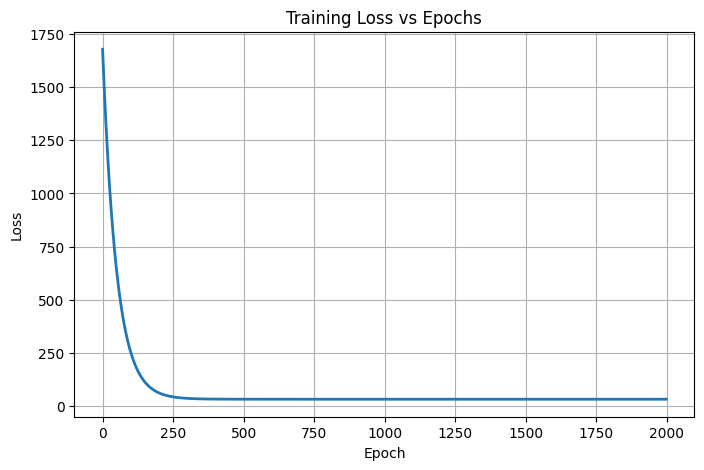

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(loss_history, linewidth=2)

plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

#### Actual vs Predicted Scores

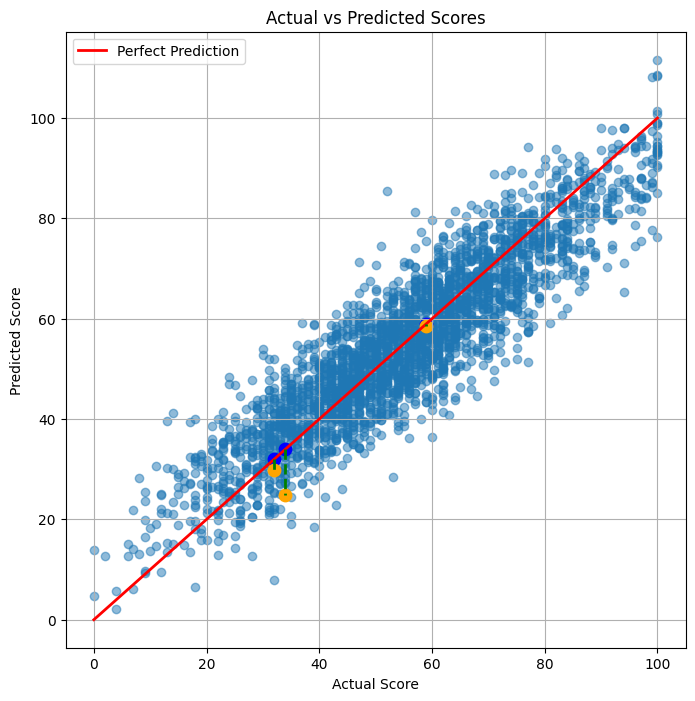

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

# Scatter all points
plt.scatter(y, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot([0,100], [0,100], color='red', linewidth=2, label='Perfect Prediction')

# Show error lines for first 3 students
indices = [0, 1, 2]

for i in indices:
    # Vertical line from actual score to predicted score
    plt.plot([y[i], y[i]], [y[i], y_pred[i]], 'g--', linewidth=2)

    # Highlight the two points
    plt.scatter(y[i], y[i], color='blue', s=80)
    plt.scatter(y[i], y_pred[i], color='orange', s=80)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")

plt.legend()
plt.grid(True)
plt.show()

#### Prediction Error Distribution

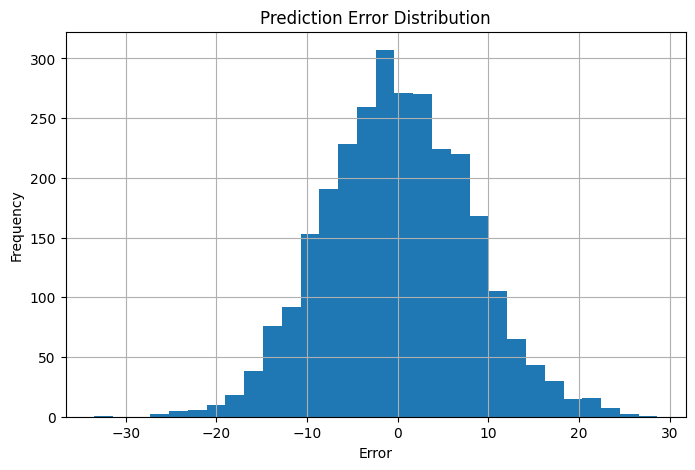

In [35]:
errors = y - y_pred

plt.figure(figsize=(8,5))

plt.hist(errors, bins=30)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

#### First 30 Students Comparison

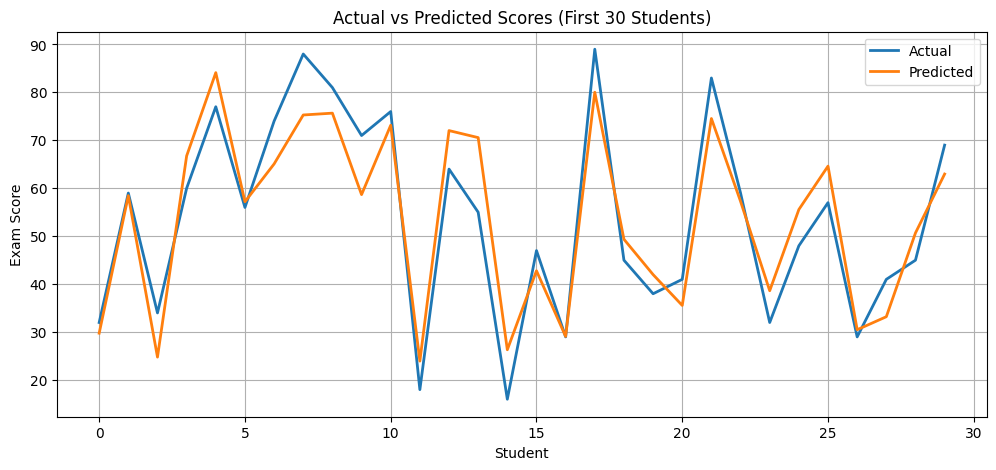

In [36]:
plt.figure(figsize=(12,5))

plt.plot(y[:30], label="Actual", linewidth=2)
plt.plot(y_pred[:30], label="Predicted", linewidth=2)

plt.xlabel("Student")
plt.ylabel("Exam Score")

plt.title("Actual vs Predicted Scores (First 30 Students)")

plt.legend()

plt.grid(True)

plt.show()